In [1]:
import pandas as pd
# Loading data
df = pd.read_csv("students.csv")
print("\nPrinting rows:", df.head())# printing rows of 5
print("\nShape of the dataset:", df.shape)#dataset shape
print("\nData Types:\n") 
print(df.dtypes)#dataset type
print("\nSummary Statistics:\n")
print(df.describe())
# count of pass and fail
print("\nPass/Fail Count:\n")
print(df['passed'].value_counts())
#Average Score per Subject
subject_columns = ['math', 'science', 'english', 'history', 'pe']
# average of pass and fail students
passing_avg = df[df['passed'] == 1][subject_columns].mean()
failing_avg = df[df['passed'] == 0][subject_columns].mean()
print("\nAverage Scores (Passing Students):\n")
print(passing_avg)
print("\nAverage Scores (Failing Students):\n")
print(failing_avg)
# Highest Average
df['average_score'] = df[subject_columns].mean(axis=1)
top_student = df.loc[df['average_score'].idxmax()]
print("\nTop Student (Highest Overall Average):\n")
print(top_student[['name', 'average_score']])


Printing rows:       name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of the dataset: (15, 9)

Data Types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:

            math    sci

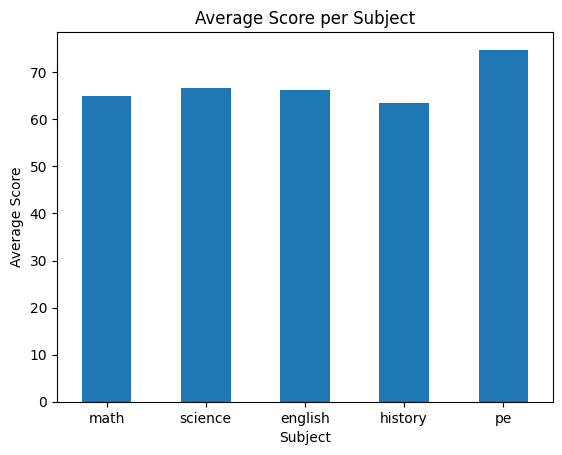

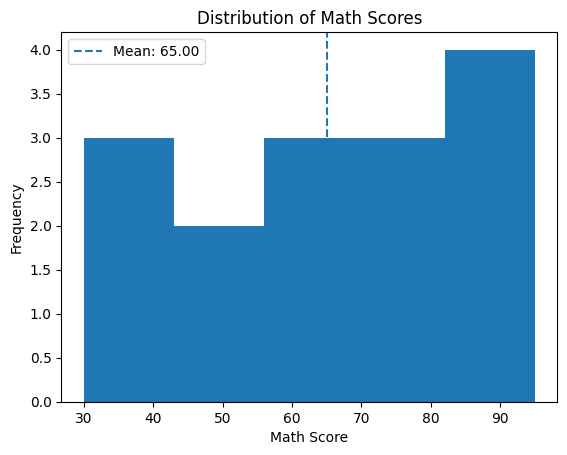

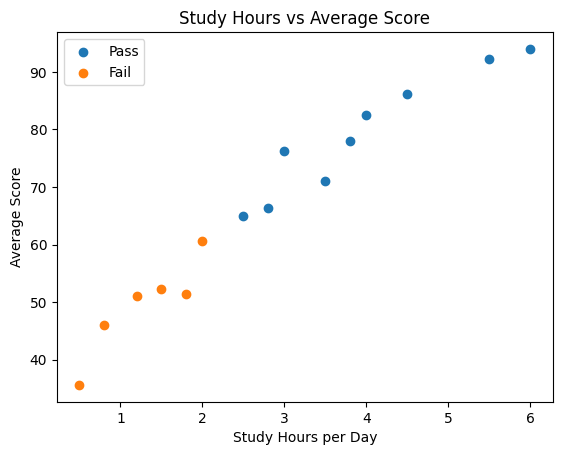

C:\Users\nalok\AppData\Local\Temp\ipykernel_28576\2806605934.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


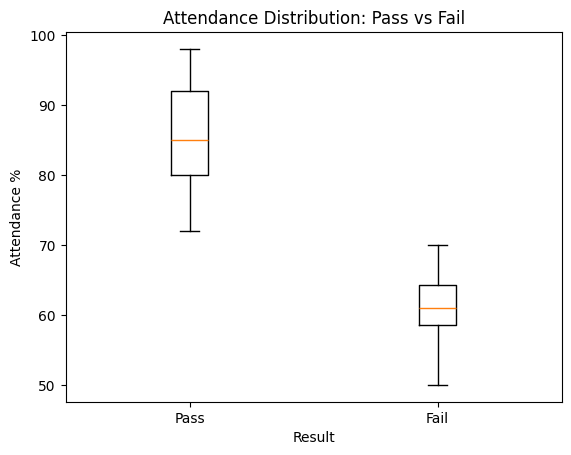

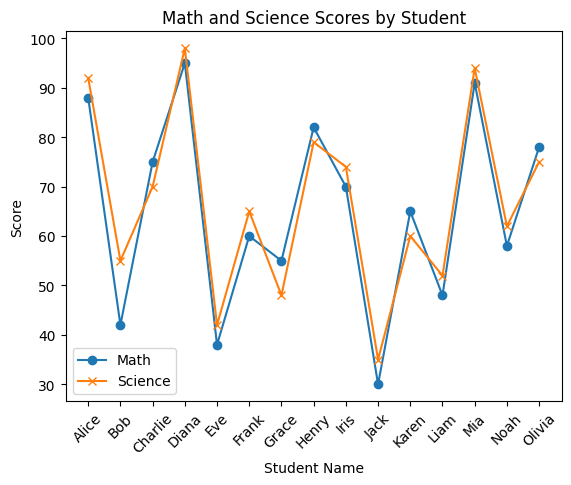

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading Data
df = pd.read_csv("students.csv")
# Adding column
subject_columns = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_columns].mean(axis=1)
# Bar Chart
avg_scores = df[subject_columns].mean()
plt.figure()
avg_scores.plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.savefig("plot1_barchart.png")
plt.show()
# Histogram
plt.figure()
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='dashed', label=f"Mean: {mean_math:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

# Scatter Plot 
plt.figure()
pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatterplot.png")
plt.show()

# Box Plot 
plt.figure()
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance %")
plt.savefig("plot4_boxplot.png")
plt.show()

# Line Plot 
plt.figure()
plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")
plt.title("Math and Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_lineplot.png")
plt.show()

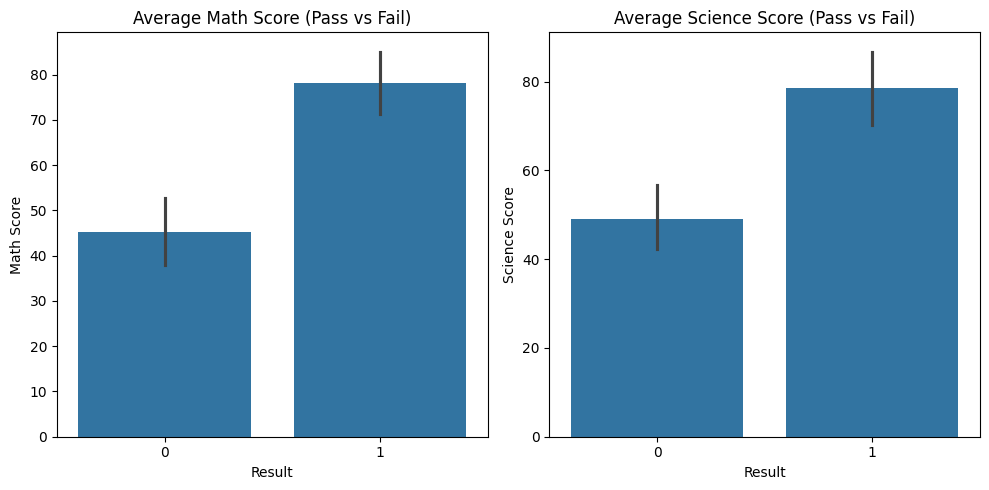

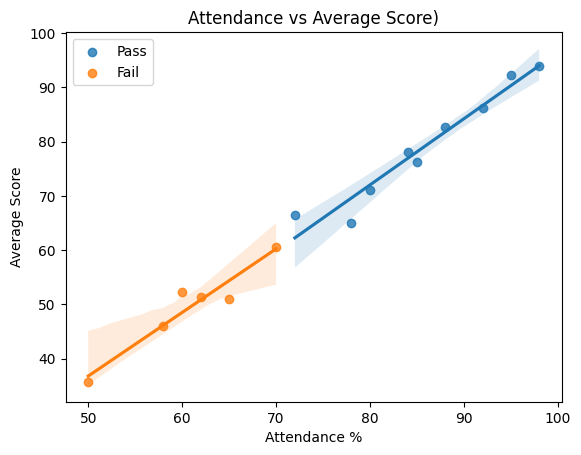

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading Data
df = pd.read_csv("students.csv")
# Add avg_score column
subject_columns = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_columns].mean(axis=1)

# Seaborn Bar 
plt.figure(figsize=(10, 5))
# Subplot 1 — Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Result")
ax1.set_ylabel("Math Score")
# Subplot 2 — Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Result")
ax2.set_ylabel("Science Score")
plt.tight_layout()
plt.savefig("seaborn_barplots.png")
plt.show()
# Seaborn scatter plot with regression lines
plt.figure()
# Pass group
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass'
)
# Fail group
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail'
)
plt.title("Attendance vs Average Score)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("seaborn_scatter_reg.png")
plt.show()


# Comparison Comment

# 1)Seaborn makes statistical plotting easier for grouped data and regression lines.
# 2)Compared to Matplotlib, it requires less manual customization, though Matplotlib provides more fine-grained control.

Training Accuracy: 1.0

Test Accuracy: 1.0

Test Predictions:

Jack: Actual=0, Predicted=0 → correct
Liam: Actual=0, Predicted=0 → correct
Alice: Actual=1, Predicted=1 → correct

Feature Importance (sorted):

english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


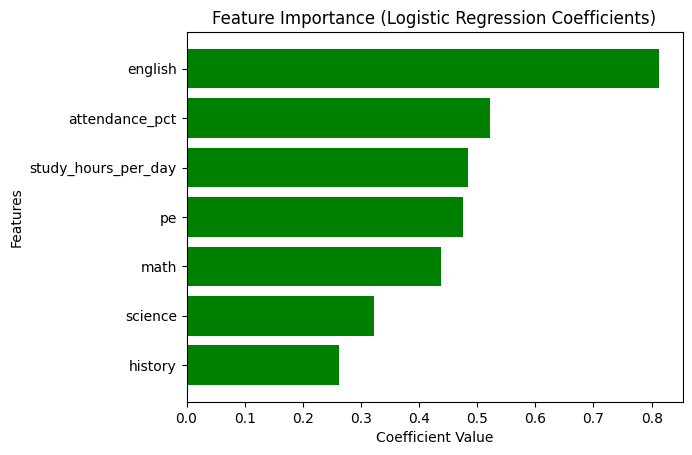


New Student Prediction:
Prediction: [1]
Probability (Fail, Pass): [[0.09203526 0.90796474]]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Loading Data
df = pd.read_csv("students.csv")
# Data preparation
feature_columns = ['math', 'science', 'english', 'history', 'pe', 
                'attendance_pct', 'study_hours_per_day']
X = df[feature_columns]
y = df['passed']
# Train data for train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)
#  Evaluating Model
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", test_acc)
print("\nTest Predictions:\n")
# Indexwise iteration
names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(names, y_test, y_pred):
    result = "correct" if actual == pred else "wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")
# Predicting co-efficients
coefficients = model.coef_[0]
important_features = list(zip(feature_columns, coefficients))
important_features.sort(key=lambda x: abs(x[1]), reverse=True)
print("\nFeature Importance (sorted):\n")
for feature, coef in important_features:
    print(f"{feature}: {coef:.4f}")
#  Horizontal bar chart
features = [f[0] for f in important_features]
coeficient = [f[1] for f in important_features]
colors = ['green' if c > 0 else 'red' for c in coeficient]
plt.figure()
plt.barh(features, coeficient, color=colors)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # highest on top
plt.savefig("feature_importance.png")
plt.show()

# Predict New Student
feature_cols = ['math', 'science', 'english', 'history', 'pe', 
                'attendance_pct', 'study_hours_per_day']
new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=feature_cols
)
new_scaled = scaler.transform(new_student)
prediction = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)
print("\nNew Student Prediction:")
print("Prediction:", prediction)
print(f"Probability (Fail, Pass): {probability}")